In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes
#from astropy.stats import sigma_clip
import vip_hci as vip
import pandas as pd
from scipy import ndimage
# %matplotlib inline
import glob
from scipy.optimize import curve_fit
from contextlib import redirect_stdout
import sys
sys.path.insert(1, '/home/gabriele/ExoDisks/gab_products/Scrypts')    # caution: path[0] is reserved for script path (or '' in REPL)
import deprojection as deproj
import ring_analysis_funcs as raf

plt.rcParams.update({ 'font.size':14, 'legend.fontsize':12})
zimp_scale = 3.516
ird_scale = 12.255
polshift = -90

### Functions definitions

In [1]:

def log_spiral( x, a, b, phi0, r0=0):
    '''x is the azimuthal position in pixel. All angle inputs in DEG'''
    phi = np.deg2rad( x - phi0 + -90 )     # from coord to actual azim angle on disk plane (-90 is the polshift)
    r = a * np.exp( b * phi) + r0
    return r

def arch_spiral( x, a, b, phi0):
    phi = np.deg2rad( x - phi0 + -90 )     # from coord to actual azim angle on disk plane (-90 is the polshift)
    r = a + b * phi
    return r


def plot_spiral( data, sp_type, a, b, r0=0, phi0=0, polshift=-90, data_bound=True):
    
    # sign = +1 if (clockwise == True) else -1    # direction of spiral increase
    x = np.arange( data.shape[1] )          # the x coordinates on the data
    phi = np.deg2rad( x - phi0 + polshift )              # the az angles corresponding to each x, centred on phi0, accounting for polshift 
    if sp_type == 'log':
        r = a * np.exp( b * phi) + r0
    else: # archimedean
        r = a + b * phi
    if data_bound:
        bound = ( r > 1 ) & ( r < data.shape[0] - 1 )
        r = r[bound]
        x = x[bound]
    return x, r


def au_to_pix( au, scale, parallax=2.85):
    return au * parallax / scale

def pix_to_au( pix, scale, parallax=2.85):
    return pix * scale / parallax

def au_deg_ticks( ax_obj, shift, pixscale):
    '''Format the ticks to put au on the Y and degrees on the X, for horizontal polar images.'''
    def au_format( value, pos):
        """The two arguments are the value and tick position"""
        x_au = pix_to_au( value, scale=pixscale)
        return f'{x_au :3.0f}'

    def deg_format( value, pos):
        x_deg = value + shift
        return f'{x_deg :.0f}'

    ax_obj.yaxis.set_major_locator( mpl.ticker.MultipleLocator( au_to_pix( 100, pixscale) ))
    ax_obj.yaxis.set_minor_locator( mpl.ticker.MultipleLocator( au_to_pix( 50, pixscale) ))
    ax_obj.yaxis.set_major_formatter( au_format )
    ax_obj.xaxis.set_major_locator( mpl.ticker.MultipleLocator( 90 ))
    ax_obj.xaxis.set_minor_locator( mpl.ticker.MultipleLocator( 20 ))
    ax_obj.xaxis.set_major_formatter( deg_format )   
    return



def arm_bounds( arm_ID, folder='./Datapoints4/' ):
    '''
    Find the endpoints of the spiral arm based on the sampled coordinates points of given arm.
    '''
    filelist = sorted( glob.glob( f'{folder}*{arm_ID}*.dat', recursive=True) )
    extrema = np.array([])
    for file in filelist: 
        data = np.loadtxt( file )
        points = data[1:]         # remove first line since it was a zoom click
        for i in [0,1]:     # cycle on x and y
            extrema = np.append(  extrema, [points[:,i].min(), points[:,i].max() ] )    # xmin, xmax, ymin, ymax for each file : one line
    extr = extrema.reshape(-1,4)
    xmin, ymin = extr[:,[0,2]].min( axis=0)
    xmax, ymax = extr[:,[1,3]].max( axis=0)
    return (xmin, xmax), (ymin, ymax)


def pitch_angle( sp_type, b , r_ev=40, absval=True):
    '''Returns pitch angle for given spiral tipe. r_ev is the evalutation radius to compute the archimedean pitch angle'''
    if sp_type == 'log':
        p =  np.rad2deg( np.arctan( b ) )
    else:   # arch
        p = np.rad2deg( np.arccos( r_ev/np.sqrt( b**2 + r_ev**2) ) )    # r and b must have same units
    if absval:
        p = abs(p)
    return p


def pitch_error( sp_type, b_best, stds, r_ev):
    '''Provide an error based on the one sigma distance b values.'''
    b_lo = b_best - stds[1] #* ([-1, +1])
    b_hi = b_best + stds[1]
    p_lo = pitch_angle( sp_type=sp_type, b=b_lo, r_ev=r_ev )
    p_hi = pitch_angle( sp_type=sp_type, b=b_hi, r_ev=r_ev )
    err = ( p_hi - p_lo) / 2
    return abs(err)


def fit_spiral( data, sp_type, prints=True, figure=True, arm_name='', folder='./Datapoints4/'):
    '''Fit the datapoints to the chosen spiral type equation. Prints the resulting fit parameters, the pitch angle and the chisquare.'''
    if sp_type == 'log':
        spiral_func = log_spiral
        param_bounds = ( [1, -np.inf, -360, 0], [250, np.inf, 720, 0.1] )        # limits on spiral parameters a, b, phi0, (r0 constrained)
        init_guess = ([10, -0.8, 180, 0])
    else:
        spiral_func = arch_spiral
        param_bounds = ( [1, -np.inf, -360], [250, np.inf, 720] )           # limits on spiral parameters a, b, phi0
        init_guess = ([10, -3.6, 180])

    try: errors = data[:,2]
    except: errors = None
    IN_popt, IN_pcov = curve_fit( spiral_func, xdata= data[:,0], ydata= data[:,1], sigma=errors, p0=init_guess, bounds=param_bounds, absolute_sigma=False )
    fit_stds = np.sqrt(np.diag( IN_pcov ))          # from scipy doc
    y_pred = spiral_func( data[:,0], *IN_popt)       # fit predictions
    res = y_pred - data[:,1]                        # residues
    chisq = sum( res**2 / y_pred) / ( len(data) - len(init_guess) )        # reduced chi-square
    arm_ID = arm_name.replace( 'spi_', '').replace( '_q', '').replace( '_a', '')      # clean names
    eval_rad = arm_bounds( arm_ID=arm_ID, folder=folder )[1][0]            # r_ev = ymin for each arm
    pitch_ang = pitch_angle( sp_type=sp_type, b= IN_popt[1], absval=True, r_ev= eval_rad )
    pitch_std = pitch_error( sp_type=sp_type, b_best=IN_popt[1], stds=fit_stds, r_ev= eval_rad)
    if prints:
        print( 'fit: a= %.3f [pix], b= %.3f [1/rad], phi0= %.2f [deg]' % tuple(IN_popt[0:3]) )
        if sp_type == 'log': print( f'r0 = {IN_popt[-1] :.2f} [pix]')
        print( 'Fit 1 sigma errors:', fit_stds )     # errors on a and r0 are enormous
        print( f'reduced chi-square of fit: \t {chisq :.3f}' )
        print( f'abs pitch angle: [deg] \t {pitch_ang :.2f} +/- {pitch_std :.2f} \t\t eval radius [pix]: {eval_rad}' )
    if figure:
        xsort = np.argsort( data[:,0] )     # to draw the lines monotonically
        fig, ax = plt.subplots( figsize=(7,5), constrained_layout=True)
        # au_deg_ticks( ax, -90, ird_scale)        # this only changes the label format, not the actual xy values of rows n cols
        # cnorm = mpl.colors.SymLogNorm( vmin=dataset.min(), vmax=dataset.max(), linthresh=3e-05, linscale=0.8, base=np.e)
        #ax.imshow( dataset, origin='lower', cmap='inferno', norm=cnorm )
        ax.scatter(data[:,0], data[:,1], c='tab:green', alpha=0.65)
        ax.plot( data[:,0][xsort], y_pred[xsort], c='tab:blue')
        ax.annotate( text=f'$\chi^2$ = {chisq :.2f}', xy=(0.6, 0.8), xycoords='axes fraction', color='k')
        ax.set( xlabel='$\phi$  (°)', ylabel='$r$  (pix)', title=f'{sp_type} fit: {arm_name}' )
        plt.show()
    return [ *IN_popt, pitch_ang, chisq, *fit_stds, pitch_std]



def perform_spiral_fit( folder='./Datapoints4/', figures=False):     # takes around 1s for each spiral arm
    '''
    Open all files with spiral datapoints (x,y coords), perform spiral fit and returns a dataframe with resulting parameters.
    '''
    filelist = sorted( glob.glob( f'{folder}/*.dat', recursive=True) )
    log_array = np.array([])
    arch_array = np.array([])

    for file in filelist:
        sp_name = file.replace( folder, '' ).replace( '.dat', '' )     # useful as IDs
        data = np.loadtxt( file )
        points = data[1:]         # remove first line since it was a zoom click
        log_params = fit_spiral( points, sp_type='log', prints=False, figure=figures, arm_name=sp_name, folder=folder)
        log_array = np.concatenate( ( log_array, [sp_name, 'log', *log_params]) )
        arch_params = fit_spiral( points, sp_type='arch', prints=False, figure=figures, arm_name=sp_name, folder=folder)
        arch_array = np.concatenate( (arch_array, [sp_name, 'arch', *arch_params]) )
    
    column_log = { 0:'filename', 1:'spiral_type', 2:'a', 3:'b', 4:'phi0', 5:'r0', 6:'pitch_ang', 7:'chi2', 8:'std_a', 9:'std_b', 10:'std_phi0', 11:'std_r0', 12:'std_pitch'}
    column_arch = { 0:'filename', 1:'spiral_type', 2:'a', 3:'b', 4:'phi0', 5:'pitch_ang', 6:'chi2', 7:'std_a', 8:'std_b', 9:'std_phi0', 10:'std_pitch'}
    log_df = pd.DataFrame( log_array.reshape( len(filelist), 13) )
    log_df.rename( columns= column_log, inplace=True )
    arch_df = pd.DataFrame( arch_array.reshape( len(filelist), 11 )  )
    arch_df.rename( columns= column_arch, inplace=True )

    for df in [log_df, arch_df]:     # pandas won't change dtype for many columns at once bah
        for i in range(2, df.shape[1]):
            df.iloc[:, i] = df.iloc[:, i].astype(float)

    merged_df = log_df.merge( arch_df, how='outer')
    return merged_df



def create_ext_img( fname, pixscale=ird_scale, figure=False, smoothing=0, r2_corr=True, logshift=False):
    img = vip.fits.fits.open_fits( fname)
    # centre = [511.5, 511.5]
    centre = list( ( np.array(img.shape) -1 )/2 )
    pol_img = deproj.main( fname, PA_majaxis=88.25, inclination=38.15, centre=centre, polar_shift=-90, flaring_ang=0, sigma_smooth=smoothing, badpix_thresh=None, r2correction=False, figs=False ) [1]
    pol_img = np.nan_to_num( pol_img, nan=0)                # NaNs give problems with rectifier()
    pol_img[ pol_img < 0] = 0           # remove the bkg noise (legal?)
    if r2_corr:
        pol = deproj.r2_correction( pol_img, polar=True)
    else: pol = pol_img
    if logshift:
        # pol = logvalues_shift( pol_img_r2 )
        print( "I really need logvalues_shift")
    ext = np.concatenate( [pol, pol], axis=1)         # create an extended figure along Phi axis

    if figure:
        if pixscale == ird_scale:
            cnorm = mpl.colors.SymLogNorm( vmin=ext.min(), vmax=ext.max(), linthresh=1, linscale=0.2, base=10)
        else: cnorm = None
        fig, ax = plt.subplots( figsize=(14,5))
        ax.imshow( ext, origin='lower', aspect='auto', cmap='inferno', norm=cnorm)
        au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
        ax.set( title= 'extended polar image', xlabel= '$\phi $ (°)', ylabel= '$r$  (au)', frame_on =False)
        plt.show()
    return ext

def overplot_spirals( img, spiral_df, pixscale=ird_scale, text=False, qphi=True, folder='./Datapoints4/'):
    '''
    Create a plot of the spiral arm params in df over the extended image img.
    '''
    if qphi:
        lthresh = 1     #2e-05     # just for the colormap
        lscale = 0.1
    else:
        lthresh = 2e-07
        lscale = 1
    ptitle = 'Spiral arms fit'
    fig, ax = plt.subplots( figsize=(10,6), constrained_layout=True)
    cnorm = mpl.colors.SymLogNorm( linthresh=lthresh, linscale=lscale, base=10)     # vmin=img.min(), vmax=img.max(),
    ax.imshow( img, origin='lower', cmap='inferno', norm=cnorm, aspect='auto')
    au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
    # ax.grid(True, alpha=0.4, linestyle=':')
    ax.set( title= ptitle, xlabel= '$\phi $ (°)', ylabel= '$r$  (au)', frame_on =False)
    ax.scatter( -48 + 360 - polshift, 35.5, marker='o', s=300, c='tab:cyan', alpha=0.6)     # centre of the dust TRAP
    fig.canvas.manager.set_window_title( ptitle)

    for i in range( spiral_df.shape[0]):
        col = 'lime' if spiral_df.spiral_type[i]=='log' else 'blue'
        x, y = plot_spiral( img, spiral_df.spiral_type[i], spiral_df.a[i], spiral_df.b[i], spiral_df.r0[i], spiral_df.phi0[i], polshift=-90)
        margin = 0     # pix
        xlims, ylims = arm_bounds( spiral_df.arm_name[i], folder=folder )
        ybounds = ( y > ylims[0] - margin ) & ( y < ylims[1] + margin )
        xbounds = ( x > xlims[0] - margin ) & ( x < xlims[1] + margin )
        ax.plot( x[ybounds & xbounds], y[ybounds & xbounds], lw=2, c=col, ls='--' , alpha=0.9)
        if text:
            ax.annotate( spiral_df.arm_name[i], (xlims[0]- margin +7, ylims[1]+ 1 + margin), xycoords='data', color=col)
                        # bbox=dict(boxstyle="round", fc='0.1', alpha=0.4, edgecolor='None') )      #x[y[bounds].argmax()], y[bounds].max()
    plt.show()


def overplot_running_spirals( img, spiral_df, windowsize, pixscale=ird_scale):
    '''
    Create a plot of the spiral arm running fit over the extended image img. Only for arch spirals now.
    '''
    ptitle = 'Spiral arm running fit'
    fig, ax = plt.subplots( figsize=(12,6), constrained_layout=True)
    cnorm = mpl.colors.SymLogNorm( linthresh=1, linscale=0.1, base=10)     # vmin=img.min(), vmax=img.max(), linthresh 2.e-05 
    ax.imshow( img, origin='lower', cmap='inferno', norm=cnorm, aspect='auto')
    au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
    ax.grid(True, alpha=0.4, linestyle=':')
    ax.set( title= ptitle, xlabel= '$\phi $ (°)', ylabel= '$r$  (au)', frame_on =False)
    ax.scatter( -50 + 360 - polshift, 35.5, marker='o', s=200, c='blue', alpha=0.5)     # centre of the dust TRAP
    fig.canvas.manager.set_window_title( ptitle)
    for i in range( spiral_df.shape[0]):
        x, y = plot_spiral( img, spiral_df.spiral_type[i], spiral_df.a[i], spiral_df.b[i], phi0=spiral_df.phi0[i], polshift=-90)
        margin = windowsize/2     # pix
        #xlims, ylims = arm_bounds( spiral_df.arm_name[i], folder=folder )
        #ybounds = ( y > ylims[0] - margin ) & ( y < ylims[1] + margin )
        xbounds = ( x > spiral_df.i[i] - margin ) & ( x < spiral_df.i[i] + margin )
        ax.plot( x[ xbounds], y[ xbounds], lw=2, c='cyan', ls='-' , alpha=0.2)
    plt.show()



def running_fit( image, datapoints, windsize=100, windstep=5, figures=True):
    '''
    Perform a spiral fit of a window of windsize pixels, running over the datapoints at steps of windstep.
    '''
    spiral_func = arch_spiral
    sp_type = 'arch'
    arch_array = np.array([])
    param_bounds = ( [-250, -np.inf, -360], [250, np.inf, 720] )           # limits on spiral parameters a, b, phi0

    for i in range( int(datapoints[:,0].min() + windsize/2), int(datapoints[:,0].max() - windsize/2), windstep ):   # running window on the angles axis
        points = datapoints[ (i - windsize/2 <= datapoints[:,0]) & (datapoints[:,0] < i + windsize/2) ]             # windows centred on pixel i
        phi_0, r_0 = np.median( points[:], axis=0)
        init_guess = ([r_0, -0.5, phi_0])        # a, b, phi0 guesses
        IN_popt, IN_pcov = curve_fit( spiral_func, xdata= points[:,0], ydata= points[:,1], p0=init_guess, bounds=param_bounds, absolute_sigma=False )
        fit_stds = np.sqrt(np.diag( IN_pcov ))          # from scipy doc
        y_pred = spiral_func( points[:,0], *IN_popt)       # fit predictions
        res = y_pred - points[:,1]                        # residues
        chisq = sum( res**2 / y_pred) / ( len(points) - len(init_guess) )        # reduced chi-square
        pitch_ang = pitch_angle( sp_type=sp_type, b= IN_popt[1], absval=True, r_ev= r_0 )
        pitch_std = pitch_error( sp_type=sp_type, b_best=IN_popt[1], stds=fit_stds, r_ev= r_0 )
        arch_array = np.concatenate( (arch_array, [i, 'arch', *IN_popt, pitch_ang, chisq, *fit_stds, pitch_std]) )
            
    column_arch = { 0:'i', 1:'spiral_type', 2:'a', 3:'b', 4:'phi0', 5:'pitch_ang', 6:'chi2', 7:'std_a', 8:'std_b', 9:'std_phi0', 10:'std_pitch'}
    arch_df = pd.DataFrame( arch_array.reshape( -1, 11 )  )
    arch_df.rename( columns= column_arch, inplace=True )
    for df in [arch_df]:
        for i in range(2, df.shape[1]):
            df.iloc[:, i] = df.iloc[:, i].astype(float)     # pandas won't change dtype for many columns at once bah
        df.i = df.i.astype(float)

    if figures:
        overplot_running_spirals( img=image, spiral_df=arch_df, windowsize=windsize)
        fig, ax = plt.subplots()
        ax.plot( arch_df.i -90, arch_df.pitch_ang)
        ax.set( xlabel='$\phi$ (°)', ylabel='pitch angle  (°)', xscale='linear', yscale='linear')
        plt.show()
    return arch_df

NameError: name 'ird_scale' is not defined

### Fitting code

In [3]:
# load images
#adi_fname = '/home/gabriele/ExoDisks/HD34700_27-10-2019_r/ird_specal_dc-IRD_SPECAL_MEDIAN_RESIDUAL_CUBE-cube_reduced_image_median_img.fits'      # ADI
#adi_ext = create_ext_img( adi_fname)

Qphi_fname = '/home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits'      # the Qphi frame from H band 2019 IRDIS         # Qphi
Qphi_ext = create_ext_img( Qphi_fname)

Fits HDU-0 data successfully loaded. Data shape: (1024, 1024)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   (1024, 1024)   float32   


New shape: (1023, 1023)


Fits HDU-0 data successfully loaded. Data shape: (1024, 1024)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   (1024, 1024)   float32   
New shape: (1023, 1023)
fit: a= 37.574 [pix], b= -2.181 [1/rad], phi0= 242.05 [deg]
Fit 1 sigma errors: [3.03303609e+06 4.85038172e-02 7.96946929e+07]
reduced chi-square of fit: 	 0.324
abs pitch angle: [deg] 	 4.45 +/- 0.10 		 eval radius [pix]: 28.0


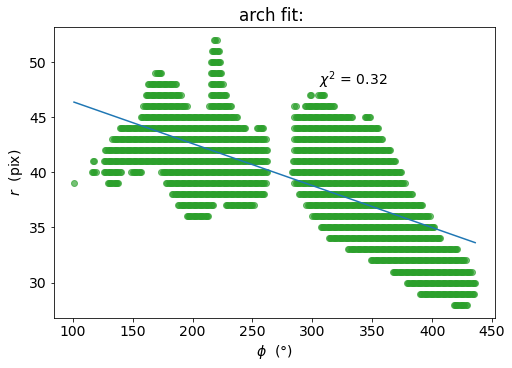

In [4]:
cont_value = 0.015
ext_NOr2 = create_ext_img( Qphi_fname, r2_corr=False)      # the r2 correction does not help the selection
rs, phis = np.nonzero( ext_NOr2 > cont_value)        # for the outring itself
lim1 = (phis > 100) & (phis < 440) #& (rs < 60)     # phis > 170 to avoid the 0-80° part
# plt.scatter( phis[lim1], rs[lim1], alpha = 0.2)
# plt.show()

# intensity = ext_NOr2[ np.nonzero(ext_NOr2 > cont_value) ]
# sigmas_n = 0.1 * intensity.max() / intensity      # the errors do not change much the fit

outring_coords = np.array( list( zip( phis[lim1], rs[lim1])) )      # , sigmas_n[lim1]
np.savetxt( './Datapoints4/outring_q.dat', outring_coords)

ringdata = np.loadtxt( './Datapoints4/outring_q.dat')
_ = fit_spiral( ringdata, 'arch')

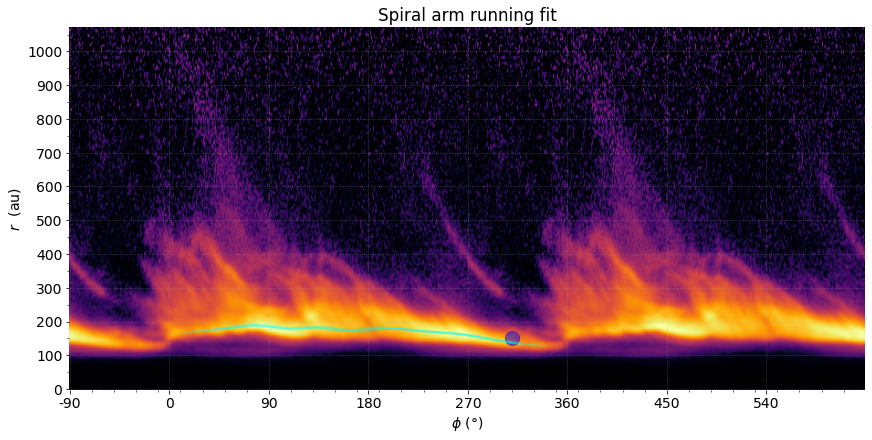

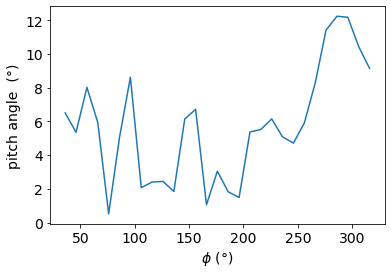

In [5]:
## A bit more fancy, with the pitch angle varying with phi
df7 = running_fit( Qphi_ext, ringdata, 50, 10)

In [6]:
fdf = perform_spiral_fit( './Datapoints4/')
# print( fdf)

o1 = fdf.loc[[3]]   # arch
s1 = fdf.loc[[2]]   # log
c1 = fdf.loc[[1]]   # log

best_df3 = pd.concat( [ s1, c1, o1], axis=0, ignore_index=True)
best_df3 = best_df3.rename( columns={'filename':'arm_name'})
best_df3.arm_name = best_df3.arm_name.str.replace( 'spi_', '').str.replace( '_q', '').str.replace( '_a', '')      # clean names
best_df3

,arm_name,spiral_type,a,b,phi0,r0,pitch_ang,chi2,std_a,std_b,std_phi0,std_r0,std_pitch
0,S1,log,149.905206,-0.687274,229.353511,0.1,34.499729,0.063131,8.079032e+07,0.049572,4.492988e+07,6.946901,1.929385
1,C1,log,28.635302,-0.604426,210.844330,0.1,31.149868,1.513364,4.465960e+07,0.187892,1.478401e+08,48.264749,7.888520
2,outring,arch,37.578837,-2.177810,242.056286,NaN,4.447450,0.323796,3.802334e+06,0.048504,1.000352e+08,NaN,0.098655


Fits HDU-0 data successfully loaded. Data shape: (1024, 1024)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   (1024, 1024)   float32   
New shape: (1023, 1023)


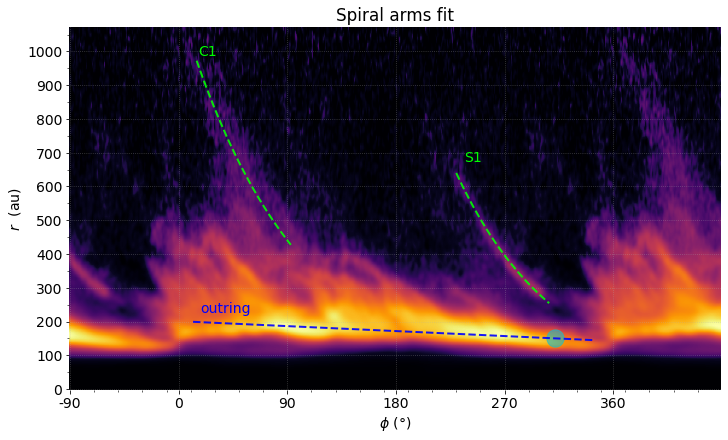

In [7]:
Qphi_ext_sm = create_ext_img( Qphi_fname, smoothing=1.6) [:, :540]
overplot_spirals( Qphi_ext_sm, best_df3, text=True, folder='./Datapoints4/')